In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from arch import arch_model
import datetime


In [2]:
#________CONFIG_______
Ticker="AAPL"
start_date = '2020-01-01'
end_date = datetime.date.today().strftime('%Y-%m-%d')

In [4]:
#DOWNLOAD 5 YEARS OF APPLE DATA
print('DOWNLOADING THE DATA')
df = yf.download(Ticker,
                 start=start_date,
                 end=end_date,       
                 interval='1d') 
print(df.head())
print(df.tail())


[*********************100%***********************]  1 of 1 completed

DOWNLOADING THE DATA
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696648  72.455966  71.472469  71.629153  146322800
2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085098  73.386416  71.631544  71.631544  132079200
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-04-23  273.429993  275.769989  271.649994  275.049988  33399600
2026-04-24  271.059998  273.059998  269.649994  272.760010  38157100
2026-04-27  267.609985  268.359985  265.070007  266.089996  41466800
2026-04-28  270.709991  273.230011  2

In [5]:
#HOW DOES THE DATA LOOKS LIKE
df.shape

(1589, 5)

In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1589.000000,1589.000000,1589.000000,1589.000000,1.589000e+03
mean,169.701653,171.439612,167.804269,169.553061,8.258449e+07
std,52.865841,53.221424,52.478580,52.848571,5.085011e+07
min,54.213608,55.211524,51.372088,55.110042,1.791060e+07
25%,133.318909,135.123163,131.619336,133.067267,4.932950e+07
50%,167.256943,168.797775,165.678294,167.267735,6.853670e+07
75%,210.150482,212.015939,207.508529,209.871334,9.794320e+07
max,285.922455,288.350192,283.035157,285.932471,4.265100e+08


In [7]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1589.000000,1589.000000,1589.000000,1589.000000,1.589000e+03
mean,169.701653,171.439612,167.804269,169.553061,8.258449e+07
std,52.865841,53.221424,52.478580,52.848571,5.085011e+07
min,54.213608,55.211524,51.372088,55.110042,1.791060e+07
25%,133.318909,135.123163,131.619336,133.067267,4.932950e+07
50%,167.256943,168.797775,165.678294,167.267735,6.853670e+07
75%,210.150482,212.015939,207.508529,209.871334,9.794320e+07
max,285.922455,288.350192,283.035157,285.932471,4.265100e+08


In [9]:
#check for missing values

print(df.isnull().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [10]:
#HOW MANY TRADING DAYS IN THE DATA SET

print(f'Total trading days:{len(df)}')
print(f"Years of data: {len(df)/252:.1f}")#:.1f means show one number after the decimal

Total trading days:1589
Years of data: 6.3


In [11]:
df.index=pd.to_datetime(df.index)#to convert the data frame into proper date foemat
gaps=df.index.to_series().diff().dt.days #Each date is subtracted from the previous date only, 
#one step at a time


print('largest gap in trading days:',gaps.max())

largest gap in trading days: 4.0


In [17]:
# Always use Adjusted Close
price = df['Close'].squeeze()
price

Date
2020-01-02     72.400528
2020-01-03     71.696648
2020-01-06     72.267937
2020-01-07     71.928047
2020-01-08     73.085098
                 ...    
2026-04-23    273.429993
2026-04-24    271.059998
2026-04-27    267.609985
2026-04-28    270.709991
2026-04-29    270.170013
Name: AAPL, Length: 1589, dtype: float64

In [18]:
#Compute returns
returns  = price.pct_change().dropna()       # simple returns
#log returns are used
log_ret  = np.log(price / price.shift(1)).dropna()  #dropna used to remove the 1st row

In [20]:
 
# ─── STEP 3: DESCRIPTIVE STATISTICS ───
print('\n=== DESCRIPTIVE STATISTICS ===')
print(f'Mean daily return:     {returns.mean()*100:.4f}%')
print(f'Std Dev (daily vol):   {returns.std()*100:.4f}%')
print(f'Annualised volatility: {returns.std()*np.sqrt(252)*100:.2f}%')
print(f'Skewness:              {returns.skew():.4f}')
print(f'Excess kurtosis:       {returns.kurtosis():.4f}')
print(f'Sharpe (annualised):   {(returns.mean()/returns.std())*np.sqrt(252):.3f}')
print(f" Normality test p-value:{ stats.shapiro(returns[:500])[1]:.4f}")# checks the data is normally distributed


=== DESCRIPTIVE STATISTICS ===
Mean daily return:     0.1026%
Std Dev (daily vol):   1.9834%
Annualised volatility: 31.49%
Skewness:              0.2797
Excess kurtosis:       6.7605
Sharpe (annualised):   0.821
 Normality test p-value:0.0000


Step-by-step logic:
Daily variance = 𝜎^2
Over 252 days:
Total variance=252×𝜎^2
Total variance=252×σ
2
Take square root:
Annual volatility
=
252
×
𝜎
2
Annual volatility=
252×σ
2
	​

=
𝜎
×
252
=σ×
252

	​


# skew= negative = left tail
# kurtosis>0 = fat tails (excess)
# Extreme events happen more often than normal distribution predicts
# p < 0.05 → returns are NOT normally distributed (typical for stocks)


In [23]:
#ADF TESTING - stationary test
#Test raw prices (expect non stationary)

result_prices = adfuller(df['Close'].dropna())
print(f'price - ADF :{result_prices[0]:.4f},p:{result_prices[1]:.4f}')

#if p>0.05 = non stationary
#prices vary very difference from each other 

price - ADF :-1.1030,p:0.7139


In [24]:
#Test returns(expect stationary)
result_ret=adfuller(returns)
print(f'Retuens - ADF :{result_ret[0]:.4f},p:{result_ret[1]:.4f}')
#typical result should be p<0.001 that is stationary
#But returns are percentages that fluctuates around some fixed mean

Retuens - ADF :-13.5176,p:0.0000


In [25]:
#INTERPRETATION HELPER
#WHAT WE DID NOW CAN BE PRINTED MORE CLEARLY
def adf_summary(result, name):
    stat, pval = result[0], result[1]
    status = 'STATIONARY ✅' if pval < 0.05 else 'NON-STATIONARY ❌'
    print(f'{name}: ADF={stat:.4f}, p={pval:.4f} → {status}')
adf_summary(result_ret,'Close')

Close: ADF=-13.5176, p=0.0000 → STATIONARY ✅


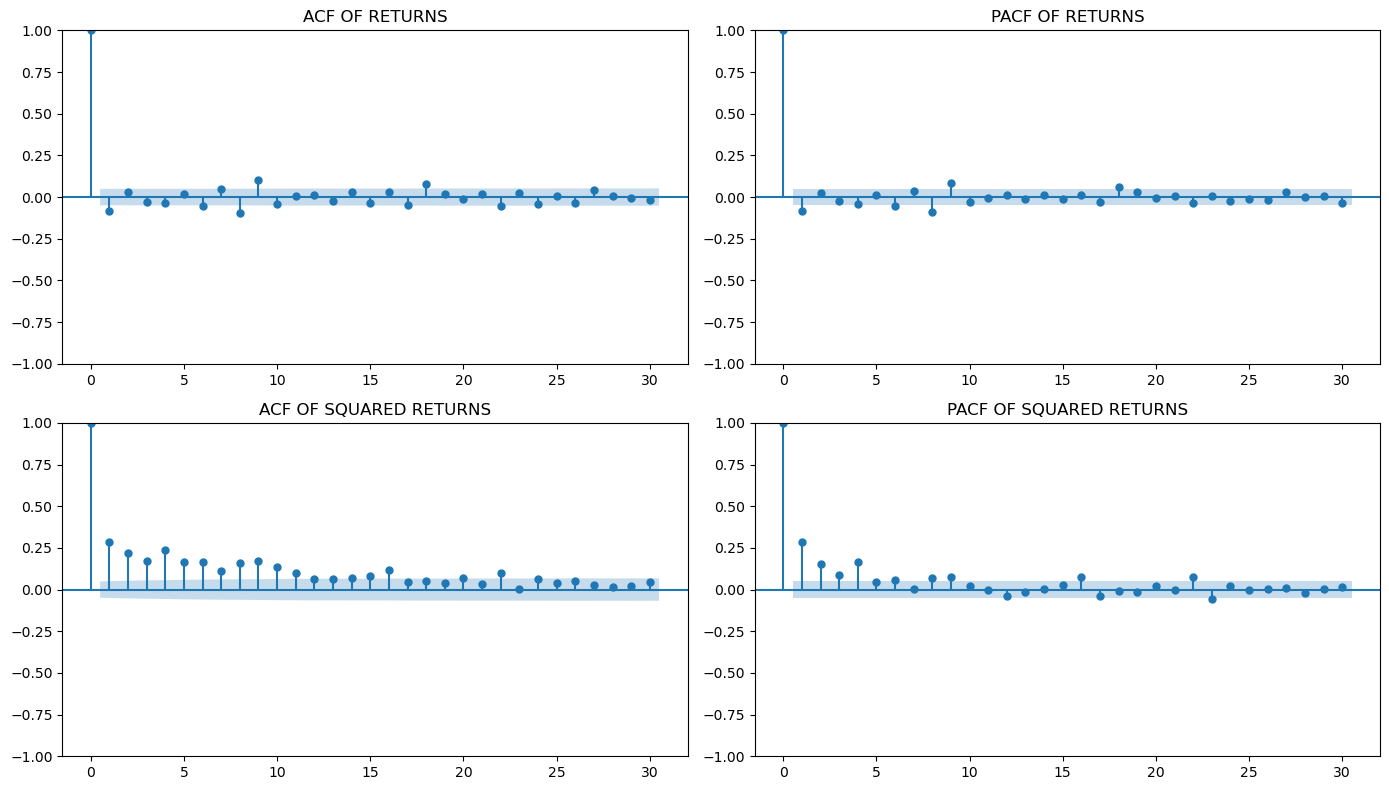

In [26]:
 #Autocorrelation (ACF)
#It shows how much the return values are related to it own lagges values
#to find a pattern




fig,axes=plt.subplots(2,2,figsize=(14,8))

#RETURNS - EXPECT LOW ACF
#corelation upto 30 previous days
plot_acf(returns,lags=30,ax=axes[0,0],title="ACF OF RETURNS")
plot_pacf(returns,lags=30,ax=axes[0,1],title="PACF OF RETURNS")

#Autocorrelation Function (ACF)
#Partial Autocorrelation Function (PACF)

#SQARED RETURNS - EXPECT HIGH ACF(VOLATALITY CLUSTERING)
#Squared returns ≈ instantaneous variance (volatility)

plot_acf(returns**2,lags=30,ax=axes[1,0],title="ACF OF SQUARED RETURNS")
plot_pacf(returns**2,lags=30,ax=axes[1,1],title="PACF OF SQUARED RETURNS")

plt.tight_layout()
plt.savefig('Autocorelation.png',dpi=150)



In [28]:

model_ar1=AutoReg(returns,lags=1).fit()
print(model_ar1.summary())
print('AR(1) COEFFICENT:',model_ar1.params[1])

#here coeff is weak negative relation beteween today and yesterday less dependence


                            AutoReg Model Results                             
Dep. Variable:                   AAPL   No. Observations:                 1588
Model:                     AutoReg(1)   Log Likelihood                3975.542
Method:               Conditional MLE   S.D. of innovations              0.020
Date:                Thu, 30 Apr 2026   AIC                          -7945.084
Time:                        12:06:39   BIC                          -7928.975
Sample:                             1   HQIC                         -7939.100
                                 1588                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      2.252      0.024       0.000       0.002
AAPL.L1       -0.0841      0.025     -3.363      0.001      -0.133      -0.035
                                    Roots           

In [ ]:
#differencing 

p_price= adfuller(df['Close'])[1] #usally p>0.05 need d=1
p_returns =adfuller(returns)[1] #usally p<0.05  d=0
print(p_price)
print(p_returns)
#1.44e-20 = 0.000000000000000000014462

In [29]:
#1st difference manually

first_diff = df['Close'].diff().dropna()
p_diff= adfuller(first_diff)[1]
print(p_diff)
#it is less than 0.05 so redy to move on to arima modelling

0.0


In [30]:
#AUTO ARIMA
!pip install pmdarima

In [ ]:
#2. ljung box test - tests for autocorelation in residuals

from statsmodels.stats.diagnostic import acorr_ljungbox
lb=acorr_ljungbox(residuals,lags=[10,20],return_df=True)
print(lb)

#Both p-values are 0.00007 and 0.00002 — extremely far below the 0.05 threshold.
#The very low p-value means there is a 99.99% certainty that autocorrelation
#still exists in the residuals.
#This is the mathematical proof that confirms what the graphs already showed visually 
#— you must move to GARCH.

Train size: 1270
Test size:  318
Test[:30] size: 30

Finding best ARIMA order...
Best order found: (1, 0, 0)
RMSE: 0.015897
MAE:  0.011681


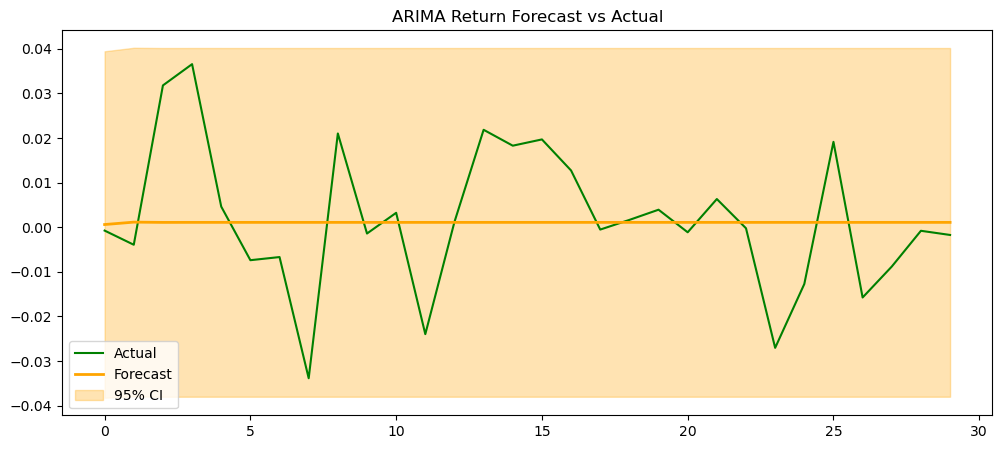

In [34]:

# Reset index to be safe
returns_clean = returns.reset_index(drop=True)

# Split data: train on 80%, test on 20%
train_size = int(len(returns_clean) * 0.8)
train = returns_clean[:train_size]
test  = returns_clean[train_size:]

print(f"Train size: {len(train)}")  # Check sizes
print(f"Test size:  {len(test)}")
print(f"Test[:30] size: {len(test[:30])}")  # Should print 30
# ─── AUTO ARIMA ───
print("\nFinding best ARIMA order...")

best_model = auto_arima(train,
                        start_p=0, max_p=5,
                        start_q=0, max_q=5,
                        d=None,          # auto detect
                        seasonal=False,
                        information_criterion='aic',
                        stepwise=True,
                        verbose=False)   # set True to see all steps

best_order = best_model.order
print(f"Best order found: {best_order}")

# Fit on training data
model = ARIMA(train, order=best_order).fit()

# Forecast next 30 days
forecast_obj  = model.get_forecast(steps=30)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)

# Reset forecast index to match test index
# making sure forecast and actual test values are on the same scale 
forecast_mean.index = range(30)
forecast_ci.index   = range(30)
test_reset = test[:30].reset_index(drop=True)

# Calculate forecast accuracy
actual    = test_reset.values
predicted = forecast_mean.values

rmse = np.sqrt(np.mean((actual - predicted)**2))#Root Mean Square Error
mae  = np.mean(np.abs(actual - predicted)) #Mean Absolute Error
print(f'RMSE: {rmse:.6f}')
print(f'MAE:  {mae:.6f}')

# Plot the forecast
plt.figure(figsize=(12, 5))
plt.plot(range(30), actual,    label='Actual',   color='green')
plt.plot(range(30), predicted, label='Forecast', color='orange', lw=2)
plt.fill_between(range(30),
                 forecast_ci.iloc[:30, 0],
                 forecast_ci.iloc[:30, 1],
                 alpha=0.3, color='orange', label='95% CI')
plt.legend()
plt.title('ARIMA Return Forecast vs Actual')
plt.savefig('arima_forecast.png', dpi=150)
plt.show()

#Green line → what actually happened
#Orange line → what ARIMA predicted

"ARIMA(1,0,0) produced a near-zero flat forecast, which is consistent with the Efficient Market Hypothesis. Returns show no predictable linear pattern, confirming that ARIMA is insufficient for this data. This motivates the use of GARCH modeling to capture volatility clustering instead."

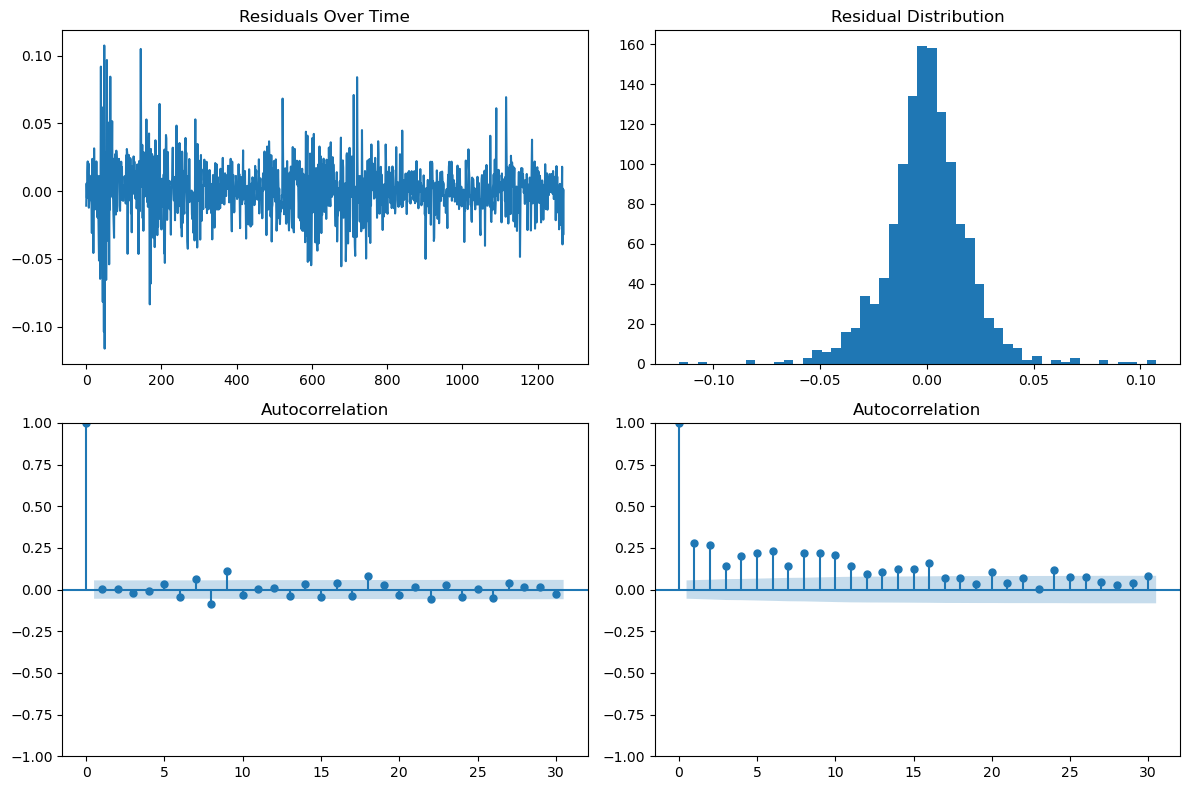

In [36]:
#check residuals

residuals=model.resid

#plot residual

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(residuals);            axes[0,0].set_title('Residuals Over Time')
axes[0,1].hist(residuals, bins=50);   axes[0,1].set_title('Residual Distribution')
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=30, ax=axes[1,0])  # should be near 0
plot_acf(residuals**2, lags=30, ax=axes[1,1])  # if significant → use GARCH
 
plt.tight_layout()
plt.savefig('arima_residualdiagnostics.png', dpi=150)
plt.show()
 

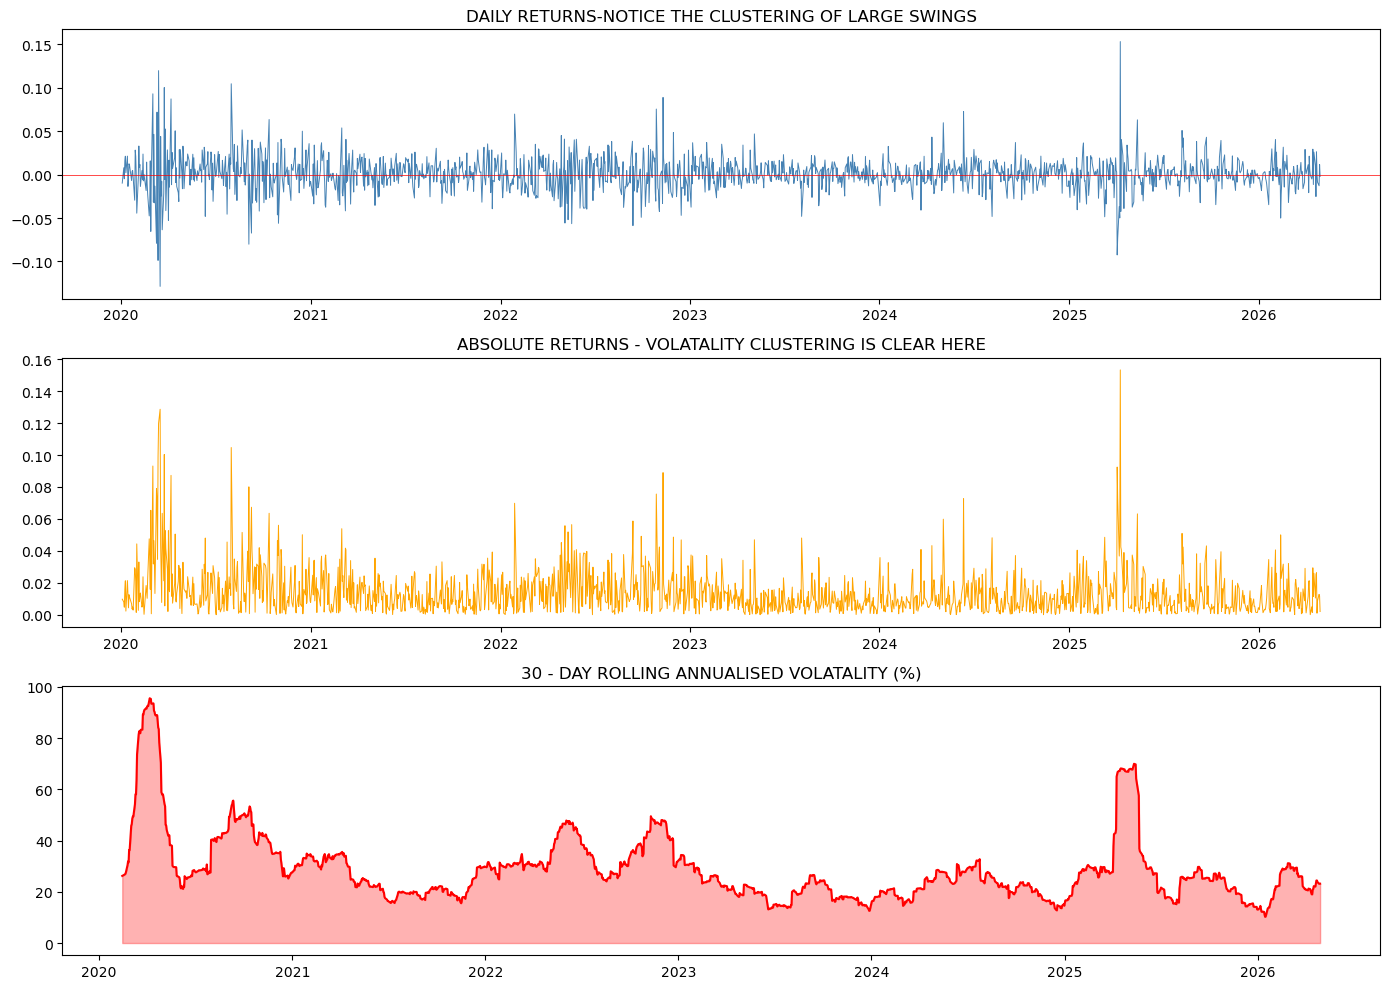

In [37]:
#GARCH

#VISUALIZE VOLATALITY CLUSTERING

#Creates a figure with 3 stacked subplots (3 rows, 1 column), sized 14×10 inches. 
fig,axes=plt.subplots(3,1,figsize=(14,10))

#Plot 1: Return series

axes[0].plot(returns,color='steelblue',linewidth=0.7)
axes[0].set_title('DAILY RETURNS-NOTICE THE CLUSTERING OF LARGE SWINGS')
axes[0].axhline(0,color='red',linewidth=0.5)

#plot 2:Absolute returns 
axes[1].plot(returns.abs(),color='orange',linewidth=0.7)
axes[1].set_title('ABSOLUTE RETURNS - VOLATALITY CLUSTERING IS CLEAR HERE')

#plot 3 : Rolling 30 day volatality

#Converts daily vol → yearly vol (252 trading days)
rolling_vol=returns.rolling(30).std() * np.sqrt(252) *100
axes[2].plot(rolling_vol,color='red',linewidth=1.5)
axes[2].fill_between(rolling_vol.index,0,rolling_vol,alpha=0.3,color='red')
axes[2].set_title('30 - DAY ROLLING ANNUALISED VOLATALITY (%)')


plt.tight_layout()
plt.savefig('Volatality_clustering.png',dpi=150)

In [ ]:
#FITTING GARCH MODEL
!pip install arch

In [38]:



#scales returns by 100 for numerical stability

r=returns*100

#fit garch(1,1) with normal distribution
gm=arch_model(r,vol='Garch',  #there are different Variance model: Garch, Egarch, GJR-Garch
             p=1,#p=1, q=1 is standard default
             q=1,
             dist='normal',  # Error distribution: normal
             mean='Constant')
res=gm.fit(disp='off')
print(res.summary())


#EXTRACT KEY PARAMETERS
# Extract key parameters
omega = res.params['omega']
alpha = res.params['alpha[1]']
beta  = res.params['beta[1]']
persistence = alpha + beta


print(f'\nomega (base variance): {omega:.6f}')
print(f'alpha (ARCH effect):   {alpha:.4f}')
print(f'beta  (GARCH effect):  {beta:.4f}')
print(f'Persistence (α+β):     {persistence:.4f}')
print(f'Long-run volatility:   {np.sqrt(omega/(1-persistence))*np.sqrt(252):.2f}% per year')



                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3160.09
Distribution:                  Normal   AIC:                           6328.18
Method:            Maximum Likelihood   BIC:                           6349.66
                                        No. Observations:                 1588
Date:                Thu, Apr 30 2026   Df Residuals:                     1587
Time:                        12:18:49   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1369  4.389e-02      3.120  1.807e-03 [5.092e-0

"Long-run variance     =  ω / (1 − α − β)
Long-run daily vol    =  √(ω / (1 − α − β))
Long-run annual vol   =  √(ω / (1 − α − β))  ×  √252  ×  (÷100 already scaled)"

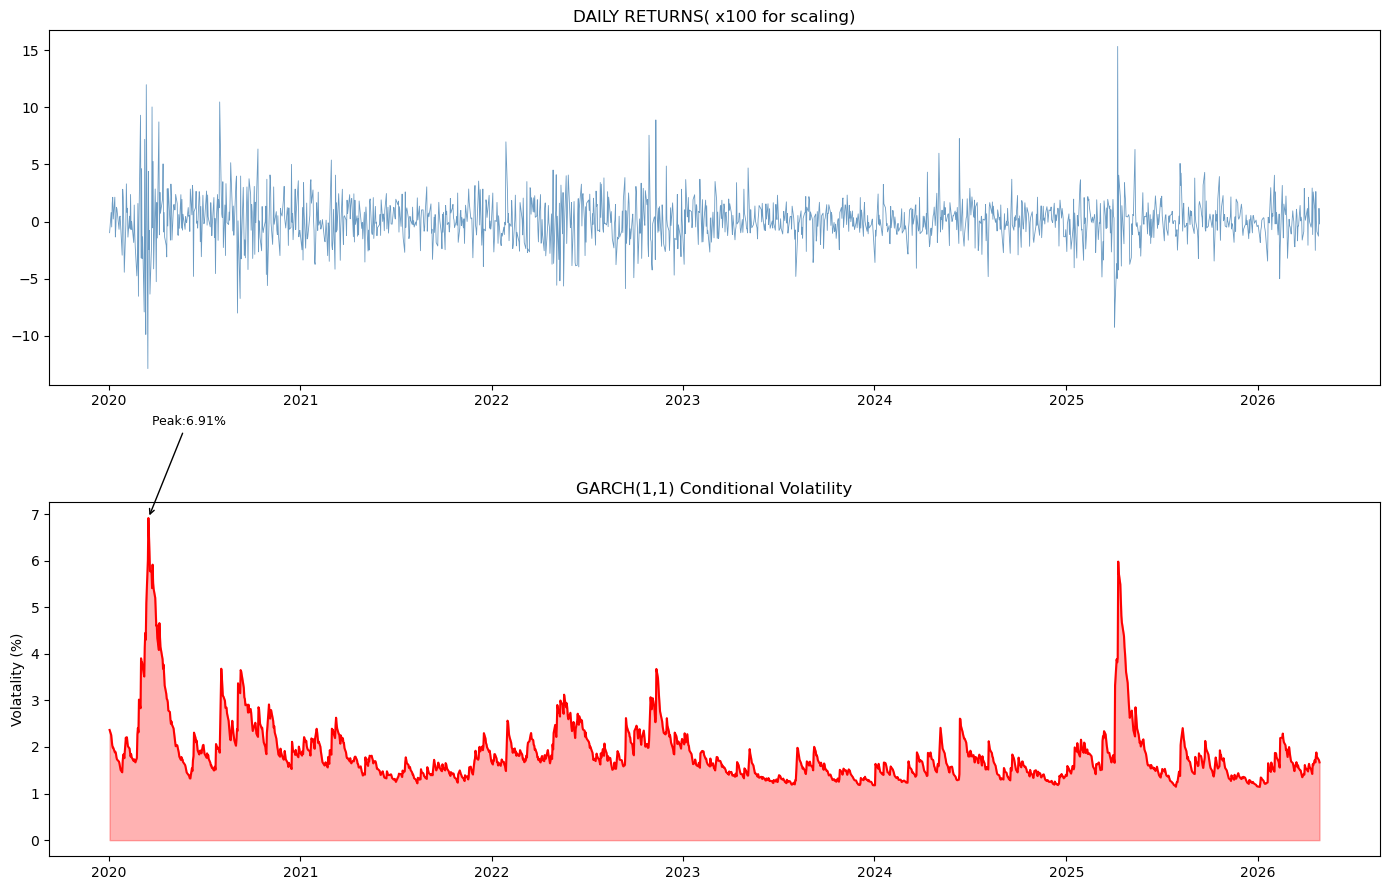

In [39]:
#GET THE ESTIMATED CONDITIONAL VOLATLITY
cond_vol=res.conditional_volatility

#plot

fig,axes=plt.subplots(2,1,figsize=(14,9))


#1st plot: Plots the raw return series in steel blue
axes[0].plot(r.index,r,color='steelblue',linewidth=0.6,alpha=0.8)
axes[0].set_title('DAILY RETURNS( x100 for scaling)')
#2md plot :Draws the volatility curve in red
axes[1].plot(cond_vol.index,cond_vol,color='red',linewidth=1.5)
axes[1].fill_between(cond_vol.index, 0, cond_vol,
                     alpha=0.3, color='red')

axes[1].set_title('GARCH(1,1) Conditional Volatility')
axes[1].set_ylabel ('Volatality (%)')

#annotate high volatility periods()like some years like covid crash

peak_date= cond_vol.idxmax()
peak_val=cond_vol.max()

axes[1].annotate(
    f" Peak:{peak_val:.2f}%",
    xy=(peak_date,peak_val),
xytext=(peak_date,peak_val +2),#places the label slightly above the actual point
arrowprops=dict(arrowstyle='->',color='black'),
fontsize=9
)

plt.tight_layout()
plt.savefig('garch_volatality.png',dpi=150)

VOLATALITY FORECAST NEXT 30 DAYS
  Day  1: 1.6012% daily  |  25.42% annualised
  Day  2: 1.6148% daily  |  25.63% annualised
  Day  3: 1.6278% daily  |  25.84% annualised
  Day  4: 1.6402% daily  |  26.04% annualised
  Day  5: 1.6521% daily  |  26.23% annualised
  Day  6: 1.6634% daily  |  26.41% annualised
  Day  7: 1.6743% daily  |  26.58% annualised
  Day  8: 1.6847% daily  |  26.74% annualised
  Day  9: 1.6946% daily  |  26.90% annualised
  Day 10: 1.7041% daily  |  27.05% annualised
  Day 11: 1.7132% daily  |  27.20% annualised
  Day 12: 1.7219% daily  |  27.33% annualised
  Day 13: 1.7302% daily  |  27.47% annualised
  Day 14: 1.7382% daily  |  27.59% annualised
  Day 15: 1.7459% daily  |  27.72% annualised
  Day 16: 1.7532% daily  |  27.83% annualised
  Day 17: 1.7603% daily  |  27.94% annualised
  Day 18: 1.7670% daily  |  28.05% annualised
  Day 19: 1.7735% daily  |  28.15% annualised
  Day 20: 1.7797% daily  |  28.25% annualised
  Day 21: 1.7856% daily  |  28.35% annualised
 

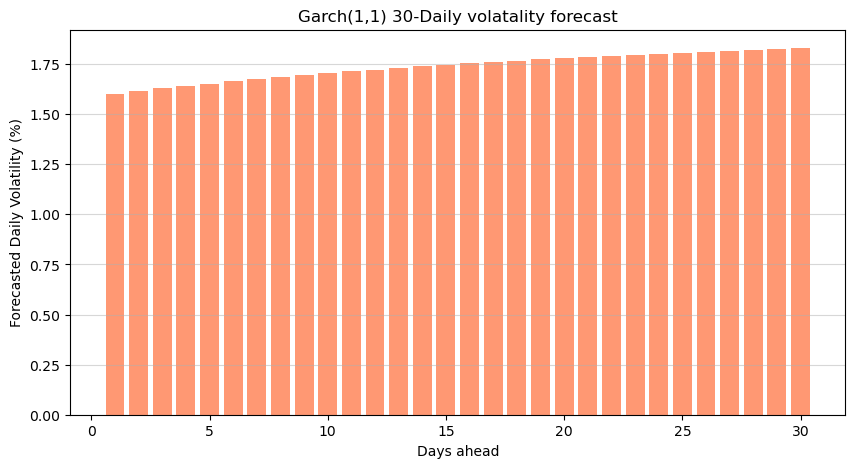

In [40]:
#GARCH VOLATALITY FORECASTING
#forecast volatality for next N days

N=30
forecasts=res.forecast(horizon=N,reindex=False)

#variance forecast (squared volatality=variance)

var_forecast=forecasts.variance.iloc[-1] #takes the last row

#convert variance to volatality
#Apply √ (square root)

vol_forecast=np.sqrt(var_forecast)
print('VOLATALITY FORECAST NEXT 30 DAYS')
for i ,v in enumerate(vol_forecast.values):
    print(f'  Day {i+1:2d}: {v:.4f}% daily  |  {v*np.sqrt(252):.2f}% annualised')
#plot forecast as barchart
plt.figure(figsize=(10,5))
plt.bar(range(1,N+1),vol_forecast.values,color='coral',alpha=0.8)    
plt.xlabel('Days ahead')
plt.ylabel('Forecasted Daily Volatility (%)')
plt.title(f"Garch(1,1) {N}-Daily volatality forecast")
plt.grid(True, axis='y', alpha=0.5)
plt.savefig('garch_forecast.png', dpi=150)




In [ ]:
#Market is currently very volatileBars go ↓ DOWN (calming down)
#Market is currently very calmBars go ↑ UP (rising to long-run avg)
#Market is at long-run averageBars stay flat 

#here looking at the bar graph: the model says the volatality is calm at 1st but it will go back to normal in 30 days

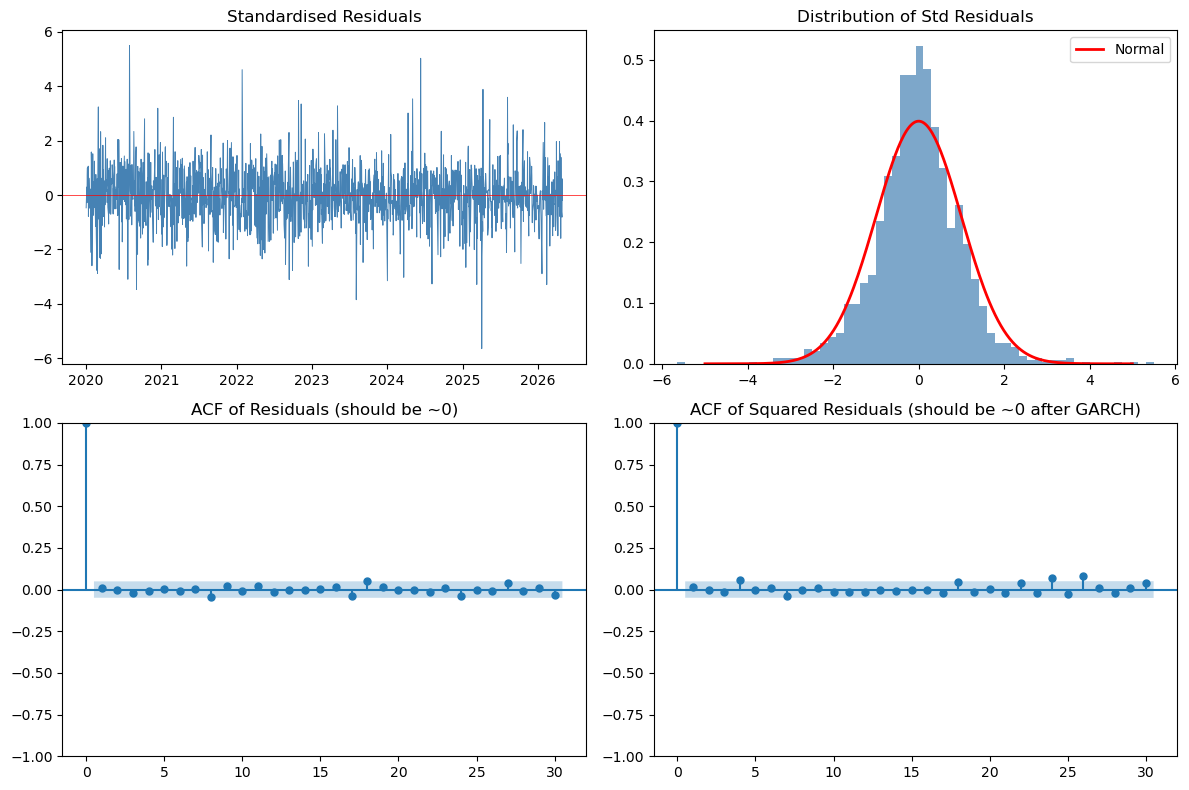

In [41]:
#Residual diaganostics to find did the model miss something
#If the model is good → residuals should be pure random noise (no patterns)
#standardised residuals
std_resid=res.std_resid
fig,axes=plt.subplots(2,2,figsize=(12,8))

#1.Time plot
axes[0,0].plot(std_resid,linewidth=0.7,color='steelblue')
axes[0,0].axhline(0,color='red',linewidth=0.5)
axes[0,0].set_title('Standardised Residuals')

#2.histogram vs normal
axes[0,1].hist(std_resid, bins=60, density=True, color='steelblue', alpha=0.7)
x = np.linspace(-5, 5, 300)
axes[0,1].plot(x, stats.norm.pdf(x), 'r-', lw=2, label='Normal')
axes[0,1].set_title('Distribution of Std Residuals')
axes[0,1].legend()
 
# 3. ACF of residuals — should be near 0

plot_acf(std_resid, lags=30, ax=axes[1,0])
axes[1,0].set_title('ACF of Residuals (should be ~0)')
 
# 4. ACF of squared residuals — should also be near 0 if GARCH fit is good
plot_acf(std_resid**2, lags=30, ax=axes[1,1])
axes[1,1].set_title('ACF of Squared Residuals (should be ~0 after GARCH)')
 
plt.tight_layout()
plt.savefig('garch_diagnostics.png', dpi=150)

[*********************100%***********************]  7 of 7 completed


Ticker   AAPL   AMZN  GOOGL     GS    JPM   MSFT   TSLA
Ticker                                                 
AAPL    1.000  0.576  0.613  0.481  0.420  0.682  0.485
AMZN    0.576  1.000  0.628  0.381  0.299  0.649  0.443
GOOGL   0.613  0.628  1.000  0.451  0.398  0.677  0.420
GS      0.481  0.381  0.451  1.000  0.819  0.462  0.360
JPM     0.420  0.299  0.398  0.819  1.000  0.414  0.298
MSFT    0.682  0.649  0.677  0.462  0.414  1.000  0.445
TSLA    0.485  0.443  0.420  0.360  0.298  0.445  1.000
Most Correlated ('GS', 'JPM') = 0.819
Most Correlated ('JPM', 'TSLA') = 0.298


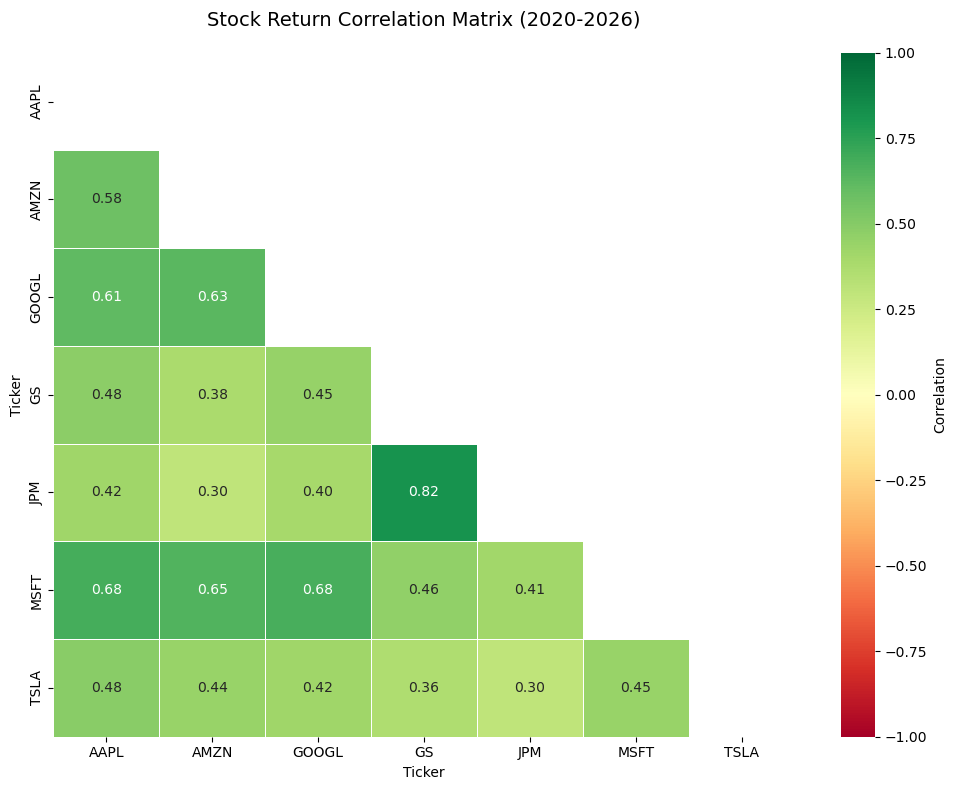

In [44]:
#correlation between stocks
#Download multiple tickers
tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'GS']
data=yf.download(tickers,start_date,end_date,auto_adjust=True)
data=data['Close']
returns_all=data.pct_change().dropna()

#computing correlation matrix
corr_matrix=returns_all.corr()
print(corr_matrix.round(3))

# Interpretation guide:
# |ρ| > 0.7  : Strong correlation
# |ρ| 0.4-0.7: Moderate correlation
# |ρ| < 0.4  : Weak correlation

#Most corelated and least
mask=~np.eye(len(corr_matrix),dtype=bool)
flat_corr = corr_matrix.where(mask).stack()
print('Most Correlated',flat_corr.idxmax(),'=',round(flat_corr.max(),3))
print('Most Correlated',flat_corr.idxmin(),'=',round(flat_corr.min(),3))


#heatmap
# Beautiful heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'},
    ax=ax
)
ax.set_title('Stock Return Correlation Matrix (2020-2026)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)


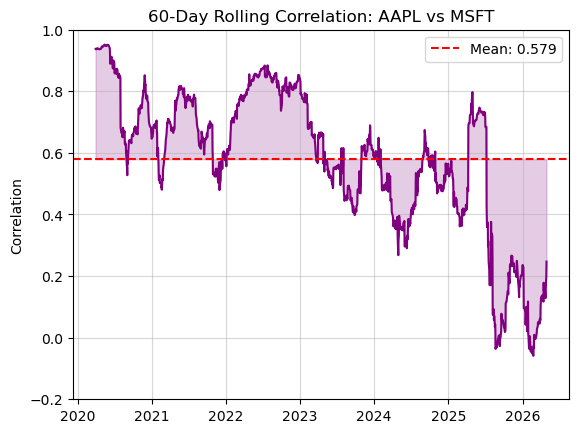

In [45]:
#ROLLING CORRELATION
#step 1 defing the pair
pair = ('AAPL', 'MSFT')
#Step 2: Calculate Rolling Correlation
rolling_corr = returns_all[pair[0]].rolling(60).corr(returns_all[pair[1]])

#plot the line
plt.plot(rolling_corr.index,rolling_corr,color='purple',linewidth=1.5)

#refernce line
plt.axhline(rolling_corr.mean(), color='red', linestyle='--',
            label=f'Mean: {rolling_corr.mean():.3f}')

plt.fill_between(rolling_corr.index, rolling_corr.mean(),
                 rolling_corr, alpha=0.2, color='purple')
plt.title(f'60-Day Rolling Correlation: {pair[0]} vs {pair[1]}')
plt.ylabel('Correlation')
plt.ylim(-0.2, 1.0)
plt.legend()
plt.grid(True, alpha=0.5)
plt.savefig('rolling_correlation.png', dpi=150)
